<a href="https://colab.research.google.com/github/kinyuac101/Git-GitHub-Project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
import nltk
import nltk
import re
from nltk.corpus import stopwords
from nltk.collocations import *
import string
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, auc, RocCurveDisplay
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn import svm
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
import pickle
import spacy
!pip install unidecode
import unidecode
!pip install word2number
from word2number import w2n
!pip install contractions
import contractions
import re


nlp = spacy.load('en_core_web_sm')

# Remove 'no' and 'not' from SpaCy's stop words list
deselect_stop_words = ['no', 'not']
for w in deselect_stop_words:
    nlp.vocab[w].is_stop = False

pd.set_option('display.max_colwidth', None)

In [6]:
# Load the real news data
real = pd.read_csv('/content/True.csv')

# Load the fake news data
fake = pd.read_csv('/content/Fake.csv')

In [7]:
# Preview real data
real.head(6)

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   
5       White House, Congress prepare for talks on spending, immigration   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [8]:
# Preview real data
fake.head(6)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before th

In [9]:
#  Add a column called 'category' to both DataFrames which will become our taget variable
real['category'] = 1
fake['category'] = 0

In [10]:
# Combine both DataFrames
data = pd.concat([real, fake])

In [11]:
# Preview the new DataFrame head
data.head(2)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   
1  U.S. military to accept transgender recruits on Monday: Pentagon   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [12]:
# Preview the new DataFrame tail
data.tail(2)

title  \
23479                How to Blow $700 Million: Al Jazeera America Finally Calls it Quits   
23480  10 U.S. Navy Sailors Held by Iranian Military – Signs of a Neocon Political Stunt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [13]:
class dataUnderstanding(object):
    """A class that does basic Data Understanding"""

    def __init__(self, df):
        self.shape = df.shape
        self.info = df.info
        self.duplicates = df.duplicated().sum()
        self.missing = df.isna().sum()
        self.types = df.dtypes

In [14]:
# Instantiate the class
understanding = dataUnderstanding(data)

In [15]:
# Summary of the dataset
print(f"Shape:{understanding.shape}")
print()
print(understanding.info())

Shape:(44898, 5)

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     44898 non-null  object
 1   text      44898 non-null  object
 2   subject   44898 non-null  object
 3   date      44898 non-null  object
 4   category  44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB
None


In [16]:
# Check for duplicates
print(f"Duplicates: {understanding.duplicates}")

Duplicates: 209


In [17]:
# Check the number of missing values
understanding.missing

,0
title,0
text,0
subject,0
date,0
category,0


In [18]:
# Inspect the value counts in the subject column
data['category'].value_counts()

,count
category,
0,23481
1,21417


In [19]:
# Inspect the value counts in the category column
data['category'].value_counts()

,count
category,
0,23481
1,21417


In [20]:
# Inspect the date column
data['date'].nunique()

2397

In [21]:
#3.1 Validity
# Converting the subject column to category
data['subject'] = data['subject'].astype('category')

In [22]:
# Converting date from object to datetime
data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce')

# Type of the date column
data['date'].dtype

# Preview the updated DataFrame
data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [23]:
# Extract the months and the years from the date column
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.strftime('%B')

In [24]:
# Inspect the updated datatypes
data.dtypes

,0
title,object
text,object
subject,category
date,datetime64[ns]
category,int64
year,float64
month,object


In [25]:
#3.2 Consistency
# Create a dataframe for the duplicated to be inspected
duplicates  = data[data.duplicated()]
duplicates.head(3)

title  \
445        Senate tax bill stalls on deficit-focused 'trigger'   
778     Trump warns 'rogue regime' North Korea of grave danger   
892  Republicans unveil tax cut bill, but the hard work awaits   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [26]:
# Drop the duplicates
print(f"Before dropping: {len(data)}")
data.drop_duplicates(inplace=True)
print(f"After dropping: {len(data)}")

Before dropping: 44898
After dropping: 44688


In [27]:
#3.4 Uniformity
# Check the value counts of the subject column
data['subject'].value_counts()

,count
subject,
politicsNews,11220
worldnews,9991
News,9050
politics,6838
left-news,4458
Government News,1570
US_News,783
Middle-east,778


In [28]:
# Rename the categories in the subject column
data['subject'].replace({'politicsNews': 'politics',
                         'worldnews': 'world_news',
                         'News': 'news',
                         'left-news': 'left_news',
                         'Government News': 'government_news',
                         'US_News': 'us_news',
                         'Middle-east': 'middle_east'}, inplace=True)

<ipython-input-28-a02124329b02>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['subject'].replace({'politicsNews': 'politics',
<ipython-input-28-a02124329b02>:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['subject'].replace({'politicsNews': 'politics',


In [29]:
# Preview the updated subject column value counts
data['subject'].value_counts()

,count
subject,
politics,18058
world_news,9991
news,9050
left_news,4458
government_news,1570
us_news,783
middle_east,778


In [30]:
#3.5.1 Univariate Analysis
# Create a function that visualizes the value counts of a column
def plot_bar(df, col)-> None:
    """ A function that returns a plot count of columns"""
    plt.figure(figsize=(12,8))
    sns.countplot(data=df, x = col, order=df[col].value_counts().index)
    plt.title(f"{col} count plot", fontsize=25)
    plt.ylabel("Count", fontsize=15)
    plt.xticks(rotation=45)
    plt.xlabel(f"{col}", fontsize=15)
    plt.show()

In [31]:
def plot_word_cloud(df, target, feature, i:int):
    """This fuction creates a wordcloud for the news texts"""
    real_news =df[df[target]==i]
    text = data[feature].values
    wordcloud = WordCloud(
        max_words = 400,
        width = 800,
        height = 600,
        background_color = 'black',
        stopwords = STOPWORDS).generate(str(text))
    fig = plt.figure(
        figsize = (14, 8),
        facecolor = 'k',
        edgecolor = 'k')
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

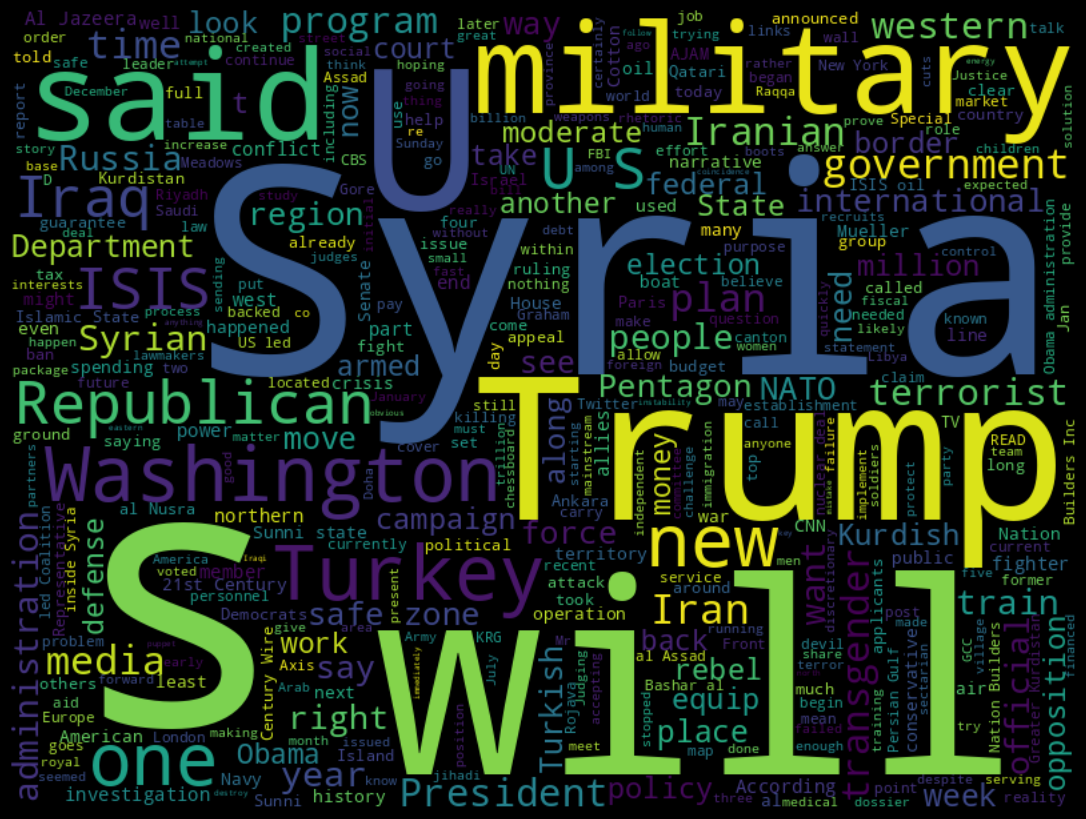

In [32]:
#Fake News Visualization Word Cloud
plot_word_cloud(data, 'category', 'text', 0)

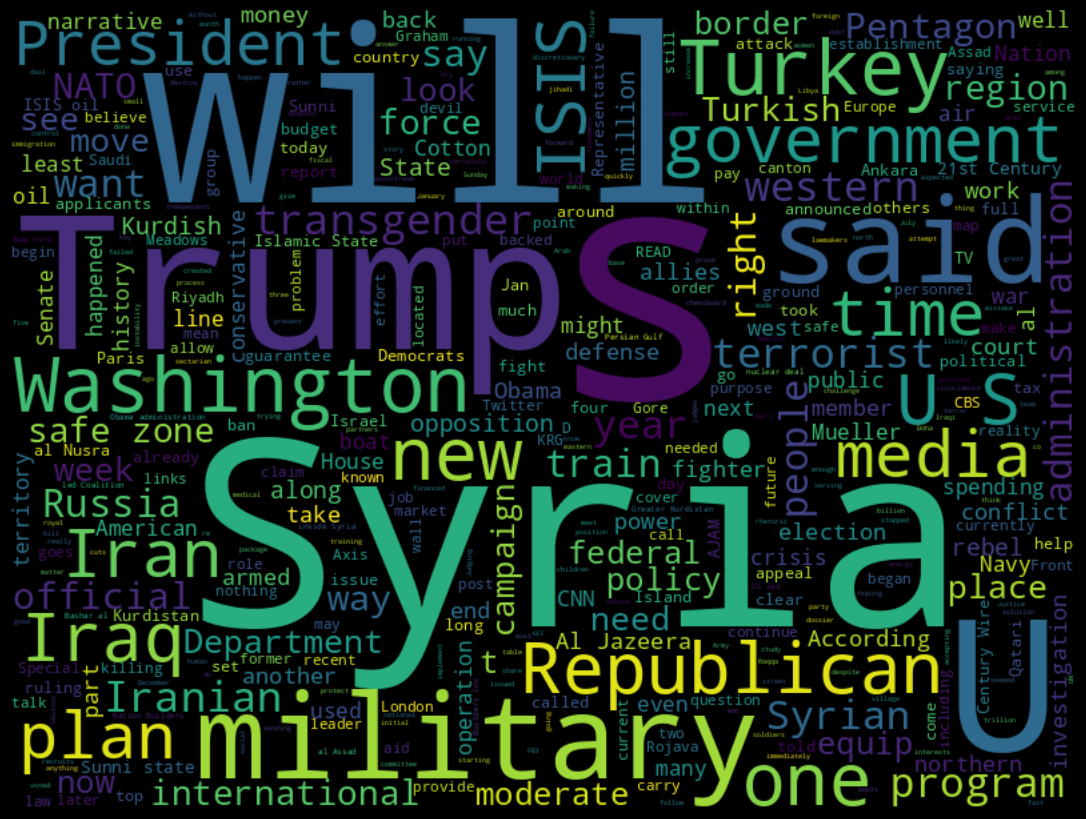

In [33]:
#Real News Visualization Word Cloud
plot_word_cloud(data, 'category', 'text', 1)

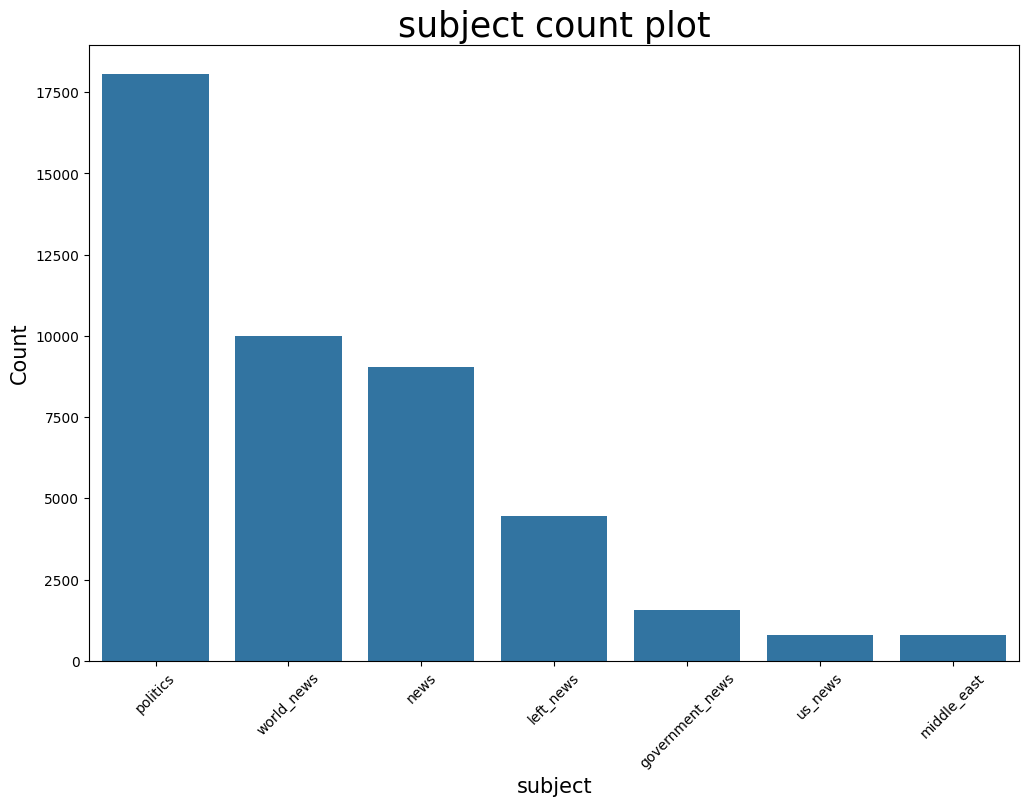

In [34]:
# Plotting a countplot of the subject
plot_bar(data, 'subject')

In [35]:
data = data.reset_index(drop=True)

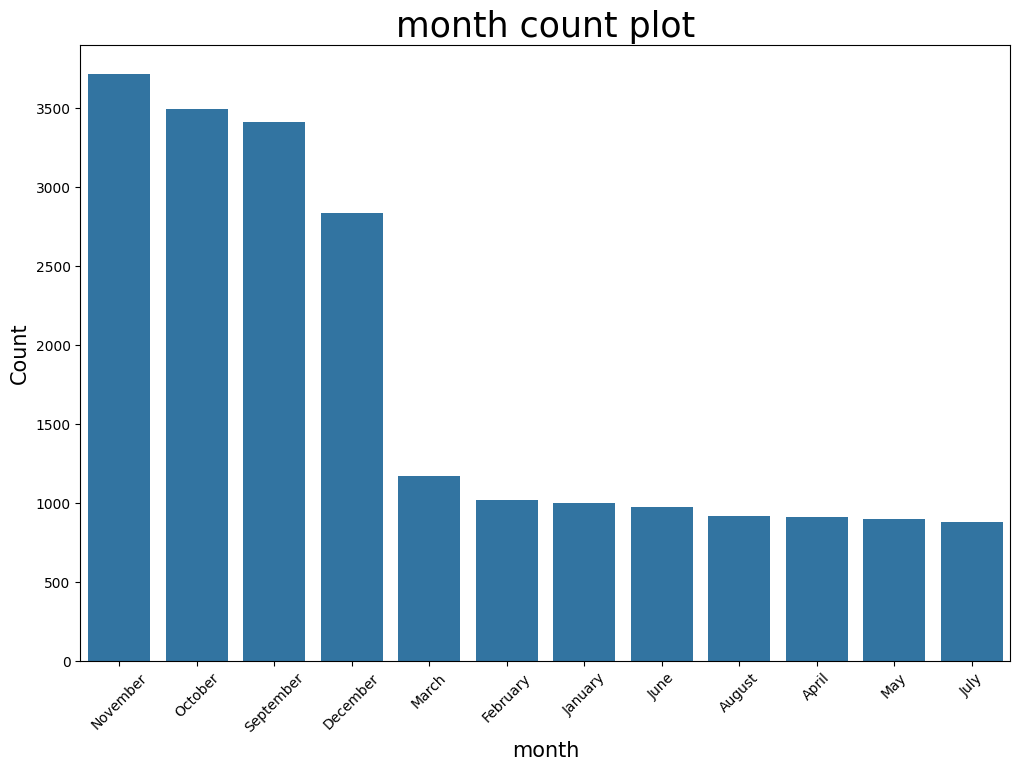

In [36]:
# Plotting a countplot of the Months
plot_bar(data, 'month')

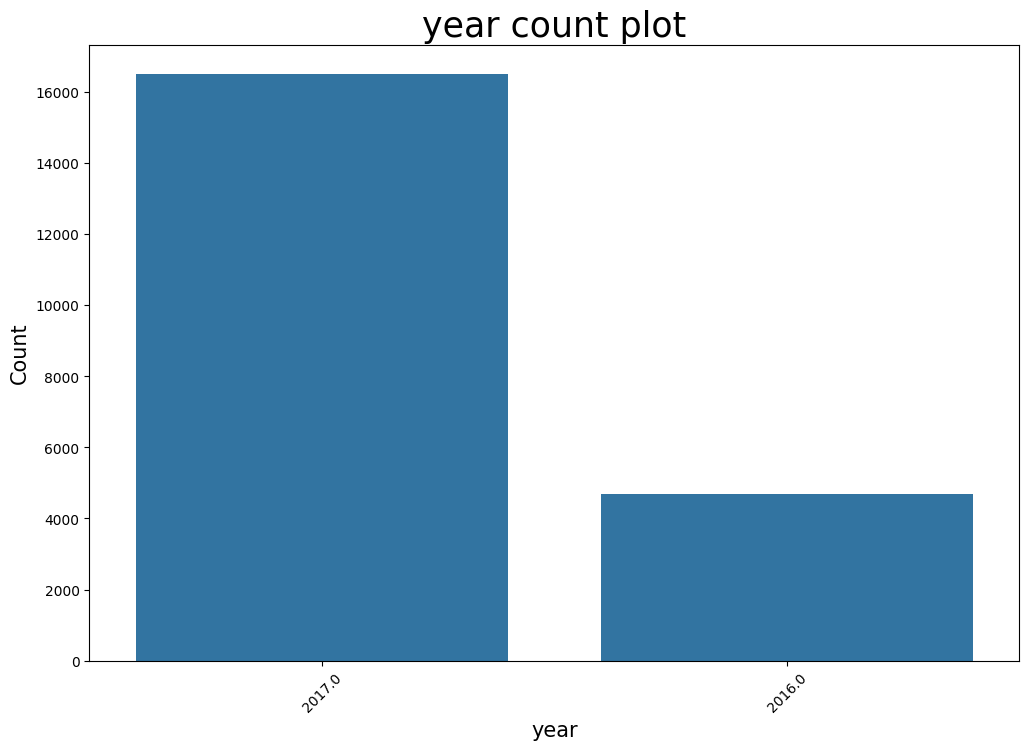

In [37]:
# Plotting the years
plot_bar(data, 'year')

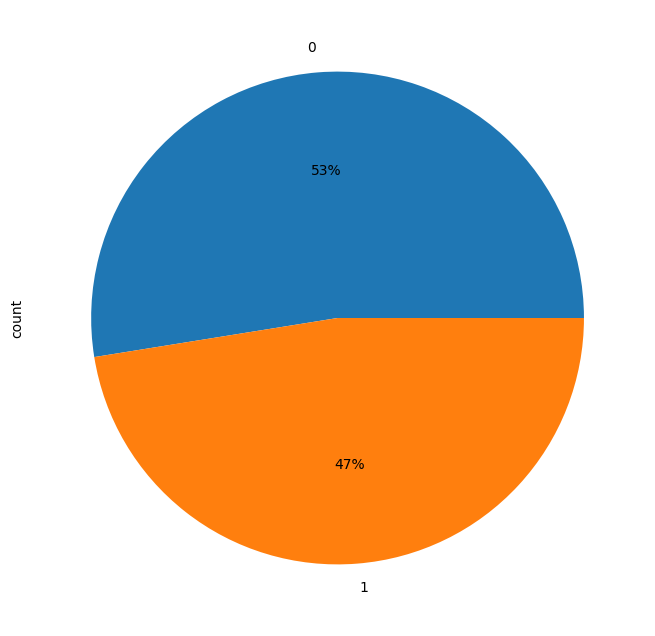

In [38]:
# Plotting a pie chart for the column 'category'
fig, ax = plt.subplots(figsize=(12,8))
data['category'].value_counts().plot(kind='pie', autopct='%.0f%%');

In [39]:
#3.5.2 Bivariate Analysis
# Creating a function that plots a count plot with respect to another column
def plot_bivariate(df, col, by):
    plt.figure(figsize=(12,8))
    sns.countplot(data=df, x=col, hue=by)
    plt.title(f"{col} count plot by {by}", fontsize=25)
    plt.ylabel("count", fontsize=15)
    plt.xticks(rotation=45)
    plt.xlabel(f"{col}", fontsize=15)
    plt.show()

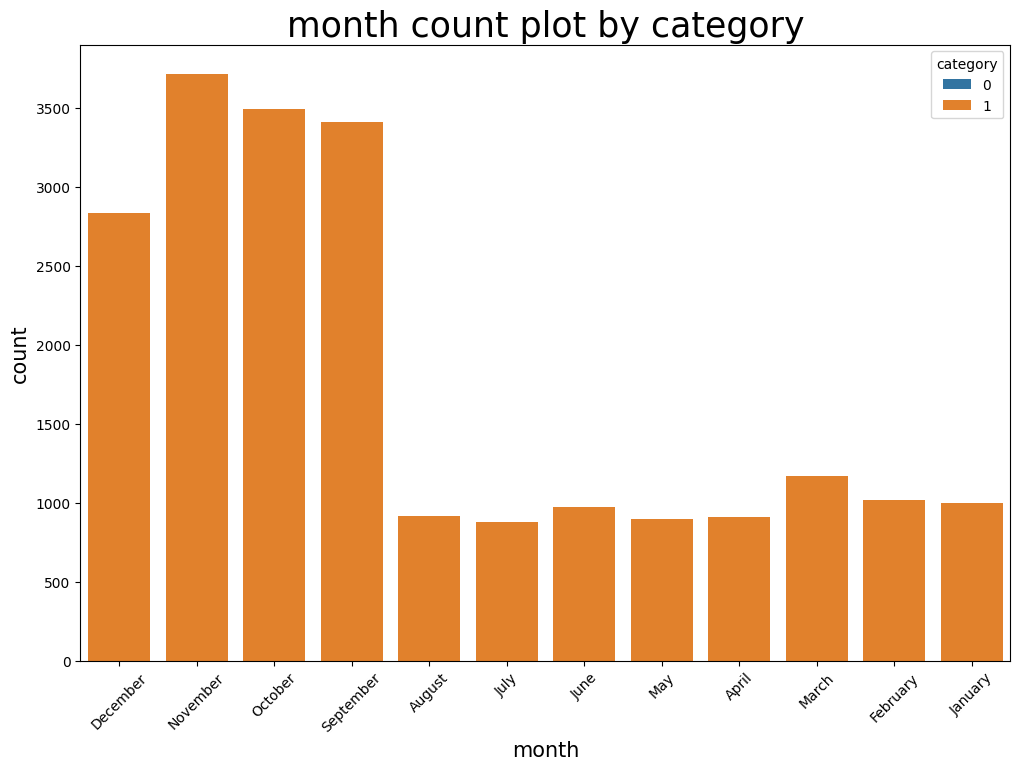

In [40]:
# Plotting month by category
plot_bivariate(data, 'month', 'category')

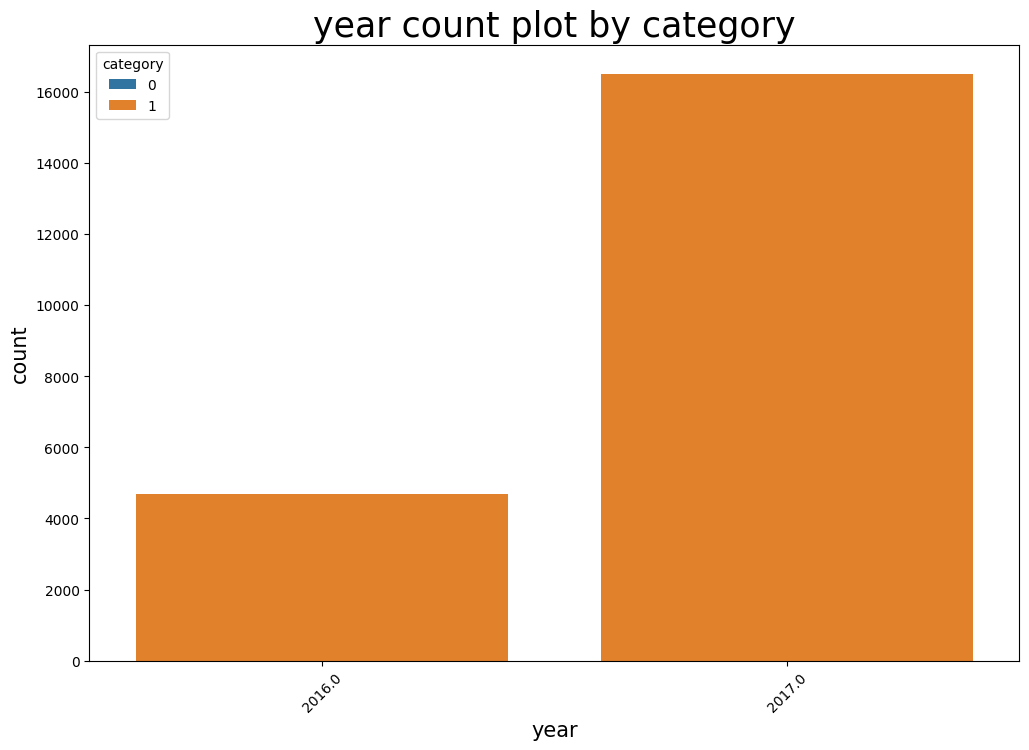

In [41]:
# plot year by category
plot_bivariate(data, 'year', 'category')

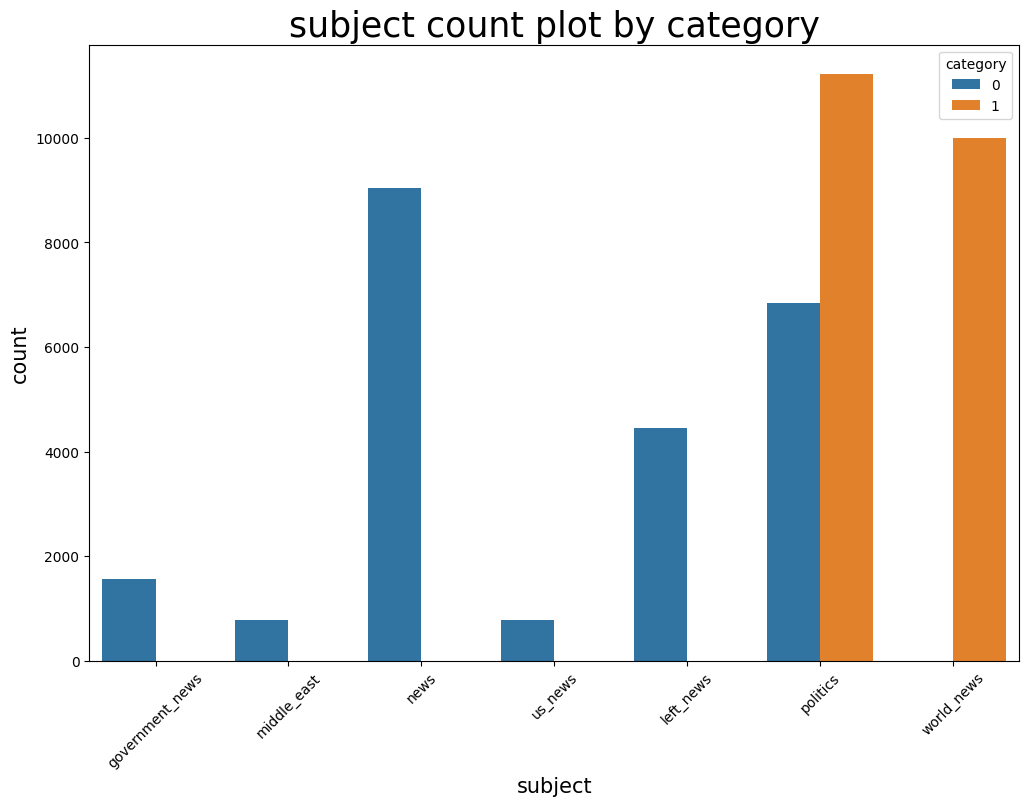

In [42]:
plot_bivariate(data, 'subject', 'category')

In [43]:
# A function to remove web tags
def remove_web_tags(text):
    """Remove html tags from a string"""
    # Remove https links
    clean = re.compile(r'https\S*')
    text = re.sub(clean, '', text)

    # Remove data '.com' links
    clean = re.compile(r'\S+\.com\S+')
    return re.sub(clean, '', text)


# Function to remove twitter handles
def remove_twitter_handles(text):
    """This function removes twitter handles from a string"""
    clean = re.compile(r'@\S*')
    return re.sub(clean, '', text)


# Function to convert Non-ASCII characters to ASCII
def remove_accented_chars(text):
    """This function removes accented characters from text, e.g. café"""
    text = unidecode.unidecode(text)
    return text


# Function to expand contractions
def expand_contractions(text):
    """Expand shortened words, e.g. don't to do not"""
    text = contractions.fix(text)
    return text


# Function to remove special characters
def remove_special_characters(text):
    """This function removes special characters from text, e.g. $"""
    clean = re.compile(r'[^a-zA-Z0-9\s]')
    return re.sub(clean, ' ', text)


# Function to lowercase text
def lowercase_text(text):
    """This function converts characters to lowercase"""
    return text.lower()


# Function to convert number words to digits
def convert_number_words(text):
    """Convert number words to digits and remove them"""

    pattern = r'(\W+)'
    tokens = re.split(pattern, text)

    for i, token in enumerate(tokens):
        try:
            tokens[i] = str(w2n.word_to_num(token))
        except:
            pass

    return ''.join(tokens)


# Function to remove numbers
def remove_numbers(text):
    """This function removes numbers from text"""
    clean = re.compile(r'\d+')
    return re.sub(clean, '', text)


# Function to remove short words
def remove_small_words(text):
    """This function removes words with length 1 or 2"""
    clean = re.compile(r'\b\w{1,2}\b')
    return re.sub(clean, '', text)


# Function to remove names of people
def remove_names(text):
    """This is a function that removes the names from text"""
    with open('./data_preprocessing/names.txt', 'r') as f:
        NAMES = set(f.read().splitlines())

        NAMES = [name.lower() for name in NAMES]

    pattern = r'\W+'
    tokens = re.split(pattern, text)

    words = tokens

    for token in tokens:
        if token in NAMES:
            while token in words:
                words.remove(token)

    text = ' '.join(words)

    return text


# Function to remove countries
def remove_countries(text):
    """This is a function that removes the countries from text"""
    with open('./data_preprocessing/countries.txt', 'r') as f:
        COUNTRIES = set(f.read().splitlines())

        COUNTRIES = [name.lower() for name in COUNTRIES]

    pattern = r'(\W+)'
    tokens = re.split(pattern, text)

    words = tokens

    for token in tokens:
        if token in COUNTRIES:
            while token in words:
                words.remove(token)

    text = ' '.join(words)

    return text


# Function to remove US cities of people
def remove_cities(text):
    """This is a function that removes the US cities from text"""
    with open('./data_preprocessing/cities.txt', 'r') as f:
        CITIES = set(f.read().splitlines())

        CITIES = [name.lower() for name in CITIES]

    pattern = r'(\W+)'
    tokens = re.split(pattern, text)

    words = tokens

    for token in tokens:
        if token in CITIES:
            while token in words:
                words.remove(token)

    text = ' '.join(words)

    return text


# Function to remove days and months
def remove_days_and_months(text):
    """This is a function that removes the months and years from text"""

    # Load the months
    with open('./data_preprocessing/months.txt', 'r') as f:
        MONTHS = set(f.read().splitlines())

        MONTHS = [name.lower() for name in MONTHS]

    # Load the days of the week
    with open('./data_preprocessing/week.txt', 'r') as f:
        WEEK = set(f.read().splitlines())

        WEEK = [name.lower() for name in WEEK]

    pattern = r'(\W+)'
    tokens = re.split(pattern, text)

    words = tokens

    for token in tokens:
        if token in MONTHS:
            while token in words:
                words.remove(token)

    for token in tokens:
        if token in WEEK:
            while token in words:
                words.remove(token)

    text = ' '.join(words)

    return text


def stopwords(text):
    """This function removes the stopwords in the text"""
    stopwords = nltk.corpus.stopwords.words('english')
    stopwords = set(stopwords)

    tokens = re.split(r'(\W+)', text)

    text = [token for token in tokens if token not in stopwords]

    return ' '.join(text)


# Function to remove extra spaces
def remove_whitespace(text):
    """Remove extra spaces from a string"""

    clean = re.compile(r'\s{2,10000}')
    text = re.sub(clean, ' ', text)

    return text


# Lemmatize text
def lemmatize(text):
    lemma = WordNetLemmatizer()

    tokens = re.split('\W+', text)

    text = [lemma.lemmatize(token) for token in tokens]

    return ' '.join(text)

In [44]:
# Remove the web tags in the text
data['text'] = data['text'].apply(remove_web_tags)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [45]:
# Remove the twitter handles from the text
data['text'] = data['text'].apply(remove_twitter_handles)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [46]:
# Remove the accented characters
data['text'] = data['text'].apply(remove_accented_chars)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [47]:
# Expand the contractions
data['text'] = data['text'].apply(expand_contractions)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [48]:
# Remove the special characters
data['text'] = data['text'].apply(remove_special_characters)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [49]:
# Lowercase the text
data['text'] = data['text'].apply(lambda x: x.lower())

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [50]:
# Convert numeric words to numbers
data['text'] = data['text'].apply(remove_numbers)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [51]:
# Remove short words (less than 3 characters)
data['text'] = data['text'].apply(remove_small_words)

data.head(1)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [52]:
# Remove the whitespace
data['text'] = data['text'].apply(remove_whitespace)

data.head(1)

,title,text,subject,date,category,year,month
0,"As U.S. budget fight looms, Republicans flip their fiscal script",washington reuters the head conservative republican faction the you congress who voted this month for huge expansion the national debt pay for tax cuts called himself fiscal conservative sunday and urged budget restraint keeping with sharp pivot under way among republicans you representative mark meadows speaking cbs face the nation drew hard line federal spending which lawmakers are bracing battle over january when they return from the holidays wednesday lawmakers will begin trying pass federal budget fight likely linked other issues such immigration policy even the november congressional election campaigns approach which republicans will seek keep control congress president donald trump and his republicans want big budget increase military spending while democrats also want proportional increases for non defense discretionary spending programs that support education scientific research infrastructure public health and environmental protection the trump administration has already been willing say are going increase non defense discretionary spending about percent meadows chairman the small but influential house freedom caucus said the program now democrats are saying that not enough need give the government pay raise percent for fiscal conservative not see where the rationale eventually you run out other people money said meadows was among republicans who voted late december for their party debt financed tax overhaul which expected balloon the federal budget deficit and add about trillion over years the trillion national debt interesting hear mark talk about fiscal responsibility democratic you representative joseph crowley said cbs crowley said the republican tax bill would require the united states borrow trillion paid off future generations finance tax cuts for corporations and the rich this one the least fiscally responsible bills have ever seen passed the history the house representatives think are going paying for this for many many years come crowley said republicans insist the tax package the biggest you tax overhaul more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear radio interview that welfare entitlement reform the party often calls would top republican priority republican parlance entitlement programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled well other programs created washington assist the needy democrats seized ryan early december remarks saying they showed republicans would try pay for their tax overhaul seeking spending cuts for social programs but the goals house republicans may have take back seat the senate where the votes some democrats will needed approve budget and prevent government shutdown democrats will use their leverage the senate which republicans narrowly control defend both discretionary non defense programs and social spending while tackling the issue the dreamers people brought illegally the country children trump september put march expiration date the deferred action for childhood arrivals daca program which protects the young immigrants from deportation and provides them with work permits the president has said recent twitter messages wants funding for his proposed mexican border wall and other immigration law changes exchange for agreeing help the dreamers representative debbie dingell told cbs she did not favor linking that issue other policy objectives such wall funding need daca clean she said wednesday trump aides will meet with congressional leaders discuss those issues that will followed weekend strategy sessions for trump and republican leaders january and the white house said trump was also scheduled meet sunday with florida republican governor rick scott who wants more emergency aid the house has 

In [53]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [54]:
import nltk
print(nltk.data.path)

['/root/nltk_data', '/usr/nltk_data', '/usr/share/nltk_data', '/usr/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [55]:
# Lemmatize the data
data['text'] = data['text'].apply(lemmatize)

data.head(1)

,title,text,subject,date,category,year,month
0,"As U.S. budget fight looms, Republicans flip their fiscal script",washington reuters the head conservative republican faction the you congress who voted this month for huge expansion the national debt pay for tax cut called himself fiscal conservative sunday and urged budget restraint keeping with sharp pivot under way among republican you representative mark meadow speaking cbs face the nation drew hard line federal spending which lawmaker are bracing battle over january when they return from the holiday wednesday lawmaker will begin trying pas federal budget fight likely linked other issue such immigration policy even the november congressional election campaign approach which republican will seek keep control congress president donald trump and his republican want big budget increase military spending while democrat also want proportional increase for non defense discretionary spending program that support education scientific research infrastructure public health and environmental protection the trump administration ha already been willing say are going increase non defense discretionary spending about percent meadow chairman the small but influential house freedom caucus said the program now democrat are saying that not enough need give the government pay raise percent for fiscal conservative not see where the rationale eventually you run out other people money said meadow wa among republican who voted late december for their party debt financed tax overhaul which expected balloon the federal budget deficit and add about trillion over year the trillion national debt interesting hear mark talk about fiscal responsibility democratic you representative joseph crowley said cbs crowley said the republican tax bill would require the united state borrow trillion paid off future generation finance tax cut for corporation and the rich this one the least fiscally responsible bill have ever seen passed the history the house representative think are going paying for this for many many year come crowley said republican insist the tax package the biggest you tax overhaul more than year will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadow making clear radio interview that welfare entitlement reform the party often call would top republican priority republican parlance entitlement program mean food stamp housing assistance medicare and medicaid health insurance for the elderly poor and disabled well other program created washington assist the needy democrat seized ryan early december remark saying they showed republican would try pay for their tax overhaul seeking spending cut for social program but the goal house republican may have take back seat the senate where the vote some democrat will needed approve budget and prevent government shutdown democrat will use their leverage the senate which republican narrowly control defend both discretionary non defense program and social spending while tackling the issue the dreamer people brought illegally the country child trump september put march expiration date the deferred action for childhood arrival daca program which protects the young immigrant from deportation and provides them with work permit the president ha said recent twitter message want funding for his proposed mexican border wall and other immigration law change exchange for agreeing help the dreamer representative debbie dingell told cbs she did not favor linking that issue other policy objective such wall funding need daca clean she said wednesday trump aide will meet with congressional leader discus those issue that will followed weekend strategy session for trump and republican leader january and the white house said trump wa also scheduled meet sunday with florida republican governor rick scott who want more emergency aid the house ha passed billion aid package after hurricane florida texas and puerto r

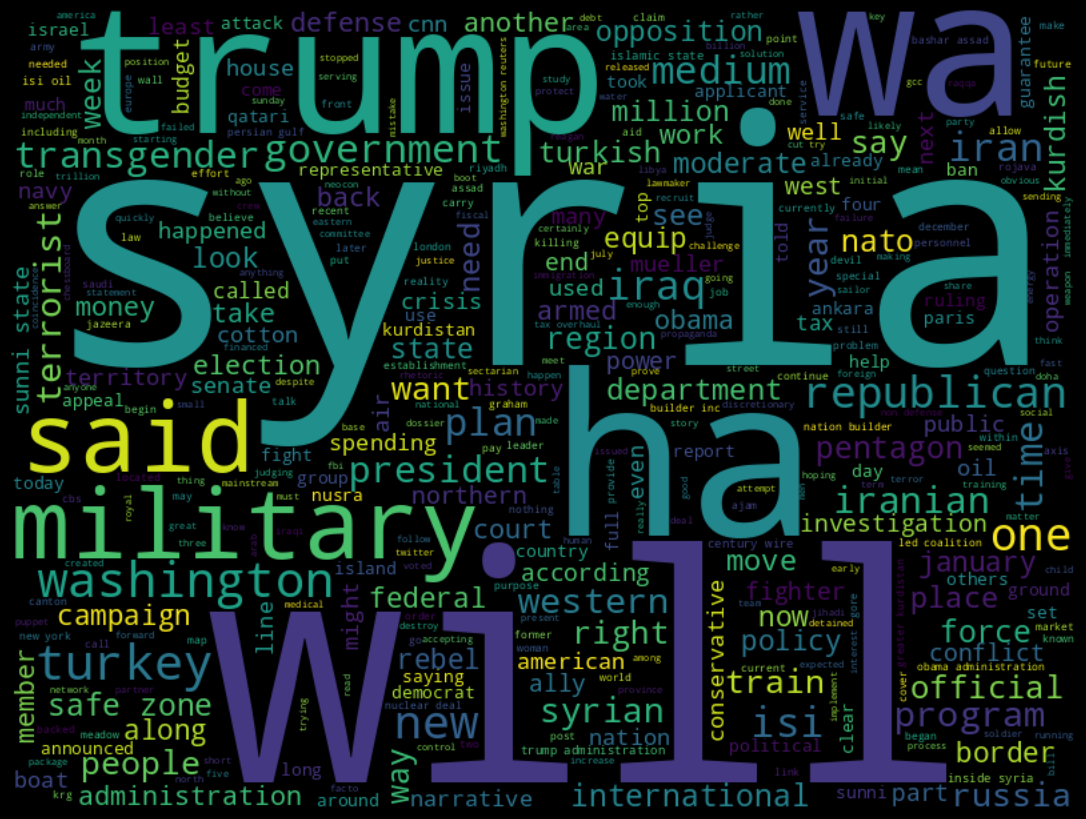

In [56]:
# WordCloud after preprocessing
plot_word_cloud(data, 'category', 'text', 0)

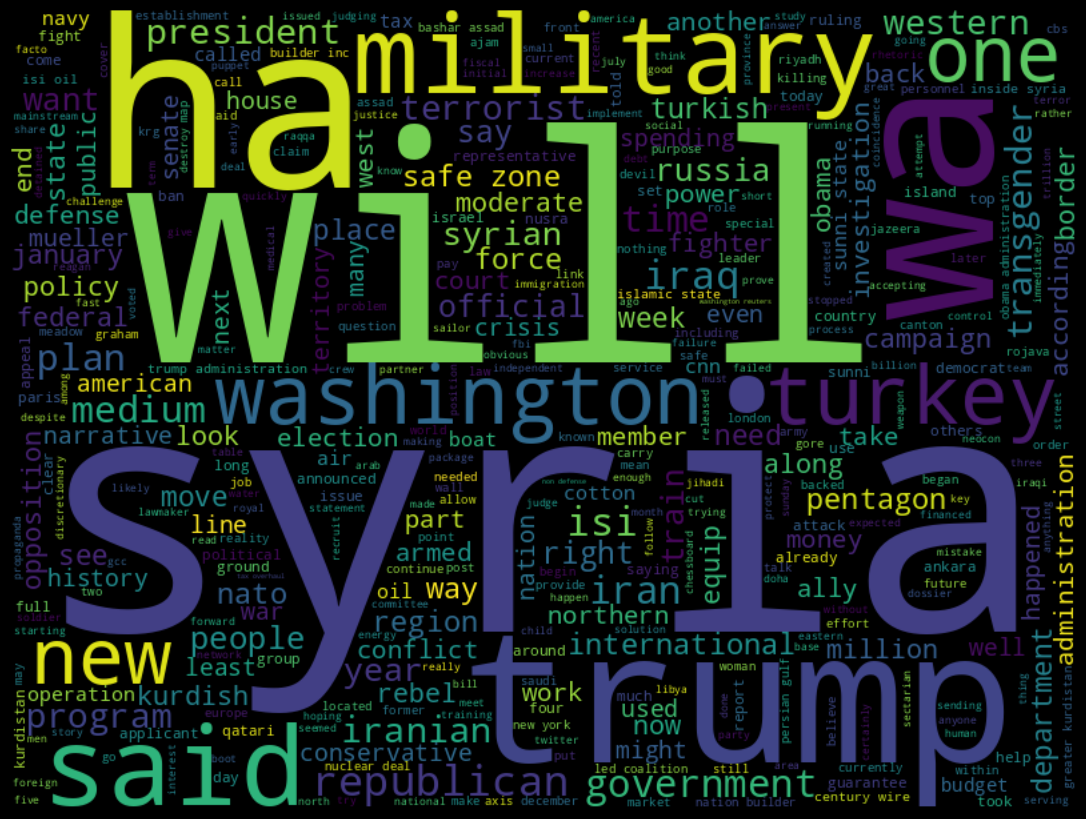

In [57]:
# WordCloud after preprocessing
plot_word_cloud(data, 'category', 'text', 1)

In [58]:
X = data['text']
y = data['category']

# Split the data into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
# Declaring a Vectoriser
tfidf_vect = TfidfVectorizer()

# 'Fitting' the Vectoriser
tfidf_vect_fit = tfidf_vect.fit(X_train)

# Creating 'Test' and 'Train' vectorised dataframes
tfidf_train = tfidf_vect_fit.transform(X_train)
tfidf_test = tfidf_vect_fit.transform(X_test)

# Checking, if we did everything alright
tfidf_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5811721 stored elements and shape (31281, 79766)>

In [60]:
# Define function to get evaluation scores and plot a confusion matrix
def score_model(model, y_test_true, X_test):
    """ A function that returns scores of a model as well as a confusion matrix"""

    y_pred = model.predict(X_test)

    precision, recall, fscore, train_support = score(y_test_true, y_pred, pos_label=1, average='binary')
    print('Precision: {} / Recall: {} / F1-Score: {} / Accuracy: {}'.format(
    round(precision, 3), round(recall, 3), round(fscore,3), round(accuracy_score(y_test_true,y_pred), 3)))

    # Create a confusion matrix
    cm = confusion_matrix(y_test_true, y_pred)

    # Make a Dataframe, of the metrics with classes
    class_label = [0, 1]
    df_cm = pd.DataFrame(cm, index=class_label,columns=class_label)

    # Plot the Model
    sns.heatmap(df_cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

Precision: 0.983 / Recall: 0.985 / F1-Score: 0.984 / Accuracy: 0.985


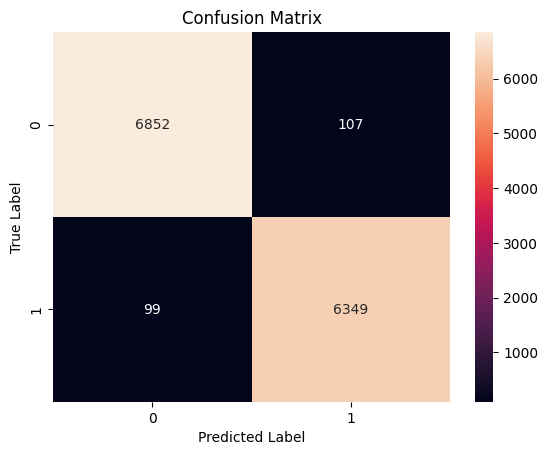

In [61]:
# Instantiate the Logistic Regression Algorithm
lr = LogisticRegression()

# Fit Algorithm
lr.fit(tfidf_train, y_train)

score_model(lr, y_test, tfidf_test)

Precision: 0.972 / Recall: 0.973 / F1-Score: 0.972 / Accuracy: 0.974


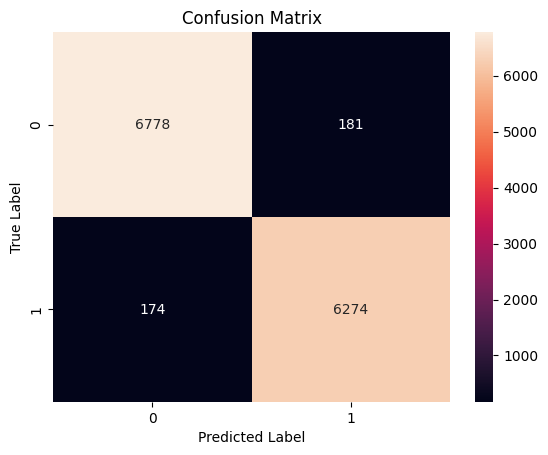

In [62]:
# Instantiate the Naive Bayes Algorithm#
rf = RandomForestClassifier(min_samples_leaf=20, min_samples_split=20, random_state=100)

# Fit Algorithm
rf = rf.fit(tfidf_train , y_train)

score_model(rf, y_test, tfidf_test)

Precision: 0.992 / Recall: 0.997 / F1-Score: 0.995 / Accuracy: 0.995


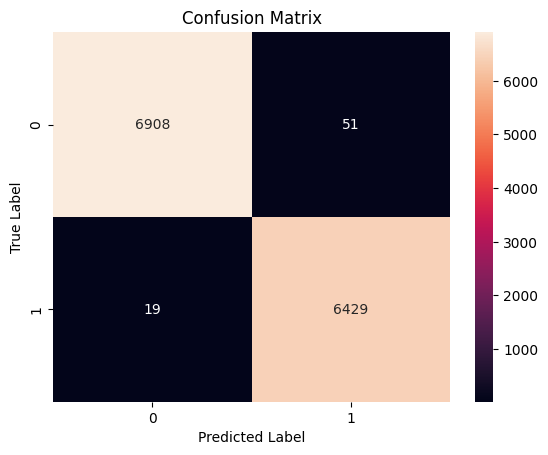

In [63]:
# Instantiating an AdaBoost Classifier
ada_boost = AdaBoostClassifier()

# Fitting the model on the training data
ada_boost.fit(tfidf_train, y_train)

# scoring the adaboost model
score_model(ada_boost, y_test, tfidf_test)

Precision: 0.992 / Recall: 0.996 / F1-Score: 0.994 / Accuracy: 0.994


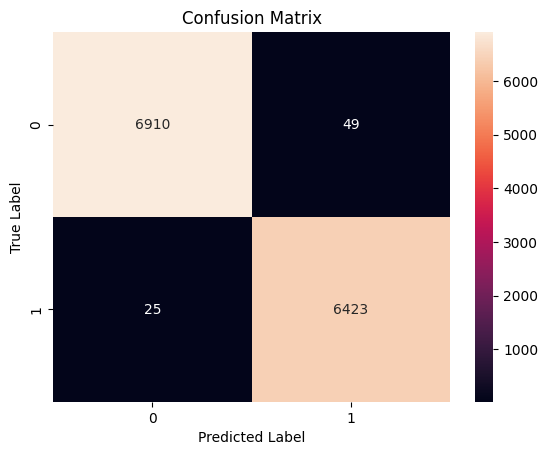

In [64]:
# Instantiating a Gradient Boosting Classifier
grad_boost = GradientBoostingClassifier()

# Fiiting to train set
grad_boost.fit(tfidf_train, y_train)

# Scoring the gradient boosting classifier
score_model(grad_boost, y_test, tfidf_test)

Precision: 0.997 / Recall: 0.998 / F1-Score: 0.998 / Accuracy: 0.998


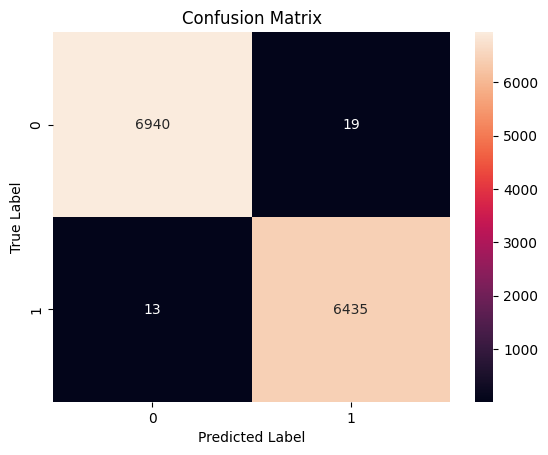

In [65]:
# Instantiating a class of XG Boost
xg_boost = XGBClassifier()

# Fitting on training data
xg_boost.fit(tfidf_train, y_train)

# scoring the XG Boost Classifier
score_model(xg_boost, y_test, tfidf_test)

In [66]:
# Creating a class that generates tpr and fpr for Area under the curve from ROC
class get_roc(object):
    """ A function that gets the roc values"""

    def train_rates(model, feature_train, target_train):
        """ A fucntion that gets the true positive rate, false positive rate and the thresholds"""

        # Calculate the fpr, tpr, and thresholds for the training set
        model_y_train_score = model.decision_function(feature_train)

        # Calculate the probability scores of each point in the train set
        model_train_fpr, model_train_tpr, model_thresholds = roc_curve(target_train, model_y_train_score)

        # Seaborn's beautiful styling
        sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

        # ROC curve for training set
        plt.figure(figsize=(10, 8))
        lw = 2
        plt.plot(model_train_fpr, model_train_tpr, color='darkorange',
                lw=lw, label='ROC curve')
        plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.yticks([i/20.0 for i in range(21)])
        plt.xticks([i/20.0 for i in range(21)])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver operating characteristic (ROC) Curve for Training Set')
        plt.legend(loc='lower right')
        print('Training AUC: {}'.format(auc(model_train_fpr, model_train_tpr)))
        plt.show()

    def test_rates (model, feature_test, target_test):
        """ A fucntion that gets the true positive rate, false positive rate and the thresholds"""
        model_y_test_score = lr.decision_function(feature_test)

        # Calculate the fpr, tpr, and thresholds for the test set
        model_test_fpr, model_test_tpr, model_test_thresholds = roc_curve(target_test, model_y_test_score)

        # Seaborn's beautiful styling
        sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

        # ROC curve for training set
        plt.figure(figsize=(10, 8))
        lw = 2
        plt.plot(model_test_fpr, model_test_tpr, color='darkorange',
                lw=lw, label='ROC curve')
        plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.yticks([i/20.0 for i in range(21)])
        plt.xticks([i/20.0 for i in range(21)])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver operating characteristic (ROC) Curve for Training Set')
        plt.legend(loc='lower right')
        print('Testing AUC: {}'.format(auc(model_test_fpr, model_test_tpr)))
        plt.show()

    def combined_rates(model, feature_train, feature_test, target_train, target_test):
        """ A function that gets the roc curves of both train and test in one plot"""
        model_y_train_score = model.decision_function(feature_train)

        # Calculate the probability scores of each point in the train set
        model_train_fpr, model_train_tpr, model_thresholds = roc_curve(target_train, model_y_train_score)

        # Calculate the probability scores of each point in the test set
        model_y_test_score = lr.decision_function(feature_test)

        # Calculate the fpr, tpr, and thresholds for the test set
        model_test_fpr, model_test_tpr, model_test_thresholds = roc_curve(target_test, model_y_test_score)

        print('Model Test AUC: {}'.format(auc(model_test_fpr, model_test_tpr)))
        print('Model Train AUC: {}'.format(auc(model_train_fpr, model_train_tpr)))

        plt.figure(figsize=(10,8))
        lw = 2

        plt.plot(model_test_fpr, model_test_tpr, color='darkorange',
         lw=lw, label='Model Test ROC curve')
        plt.plot(model_train_fpr, model_train_tpr, color='blue',
         lw=lw, label='Model Train ROC curve')

        # Formatting
        plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.yticks([i/20.0 for i in range(21)])
        plt.xticks([i/20.0 for i in range(21)])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver operating characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.show()

    def get_auc(model, feature_train, feature_test, target_train, target_test):
        """ A function that gets the roc curves of both train and test in one plot"""
        model_y_train_score = model.decision_function(feature_train)

        # Calculate the probability scores of each point in the train set
        model_train_fpr, model_train_tpr, model_thresholds = roc_curve(target_train, model_y_train_score)

        # Calculate the probability scores of each point in the test set
        model_y_test_score = lr.decision_function(feature_test)

        # Calculate the fpr, tpr, and thresholds for the test set
        model_test_fpr, model_test_tpr, model_test_thresholds = roc_curve(target_test, model_y_test_score)

        print('Model Test AUC: {}'.format(auc(model_test_fpr, model_test_tpr)))
        print('Model Train AUC: {}'.format(auc(model_train_fpr, model_train_tpr)))

Model Test AUC: 0.9979319004933898
Model Train AUC: 0.9991170642660883


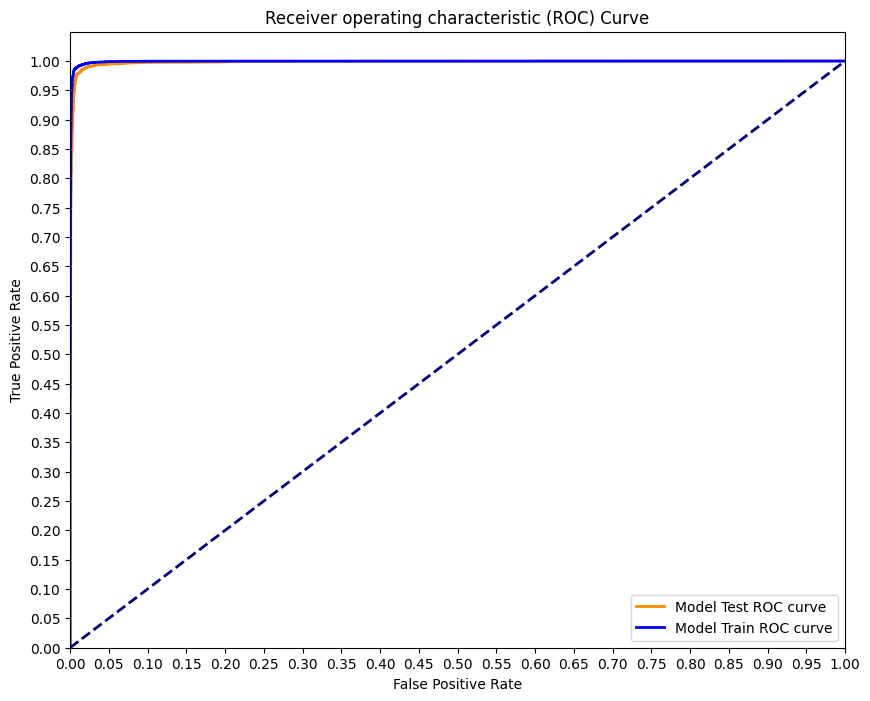

In [67]:
#Logistic Regression ROC
lr_combined = get_roc.combined_rates(lr, tfidf_train, tfidf_test, y_train, y_test)

The area under the curve of the random forest is 0.9965256668177347


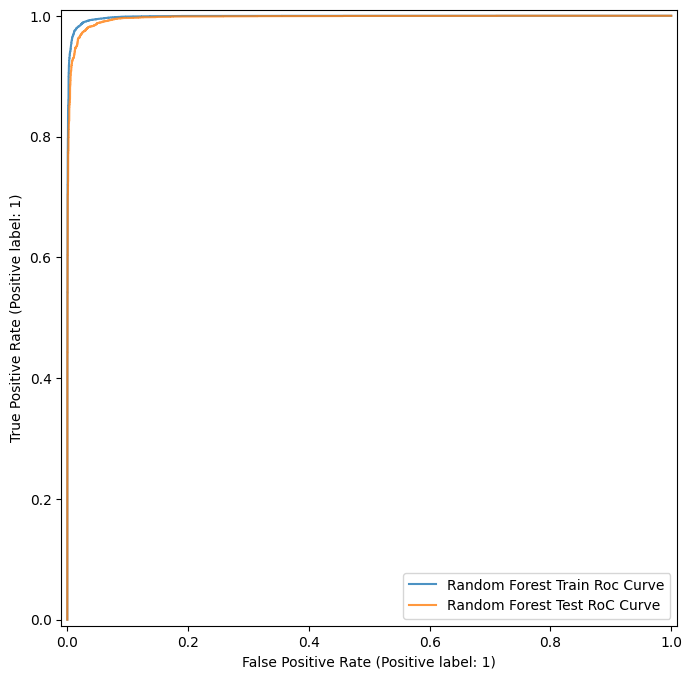

In [68]:
#Random Forest ROC
print(f"The area under the curve of the random forest is {roc_auc_score(y_test, rf.predict_proba(tfidf_test)[:,1])}")
# Plotting ROC curve for Random Forest
fig, ax = plt.subplots(figsize=(12,8))
ax = plt.gca()
rf_train = RocCurveDisplay.from_estimator(rf, tfidf_train, y_train, ax=ax, alpha=0.8, label ='Random Forest Train Roc Curve')
rf_disp = RocCurveDisplay.from_estimator(rf, tfidf_test, y_test, ax=ax, alpha=0.8, label= 'Random Forest Test RoC Curve')
plt.show()

In [69]:
#Ada Boosting Classifier ROC
print(f"The area under the curve of the Ada Boosting classifier is {roc_auc_score(y_test, ada_boost.predict_proba(tfidf_test)[:,1])}")

The area under the curve of the Ada Boosting classifier is 0.9993534556532286


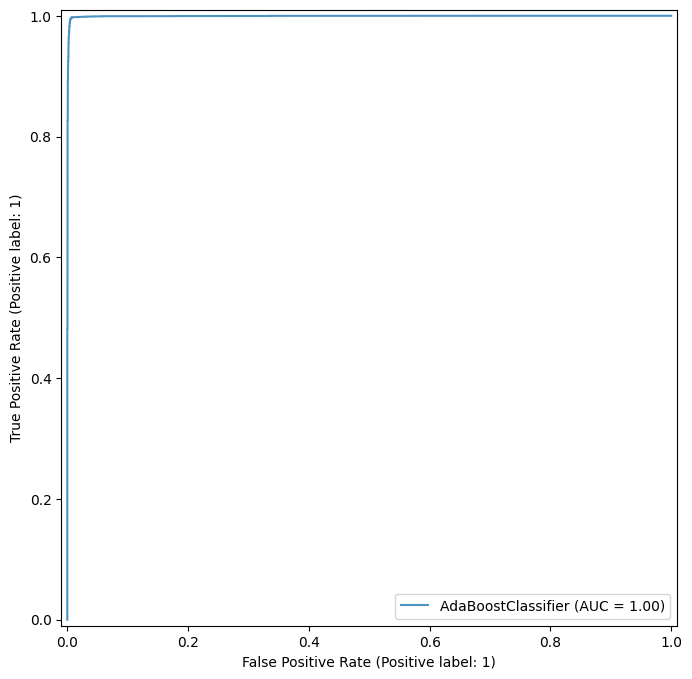

In [70]:
# Plotting ROC curve for Ada Boosting Classifier
fig, ax = plt.subplots(figsize=(12,8))
ax = plt.gca()
ada_disp = RocCurveDisplay.from_estimator(ada_boost, tfidf_test, y_test, ax=ax, alpha=0.8)
plt.show()

In [71]:
#Gradient Boosting Classifier ROC
print(f"The area under the curve of the gradient boosting classifier is {roc_auc_score(y_test, grad_boost.predict_proba(tfidf_test)[:,1])}")

The area under the curve of the gradient boosting classifier is 0.9990973361521596


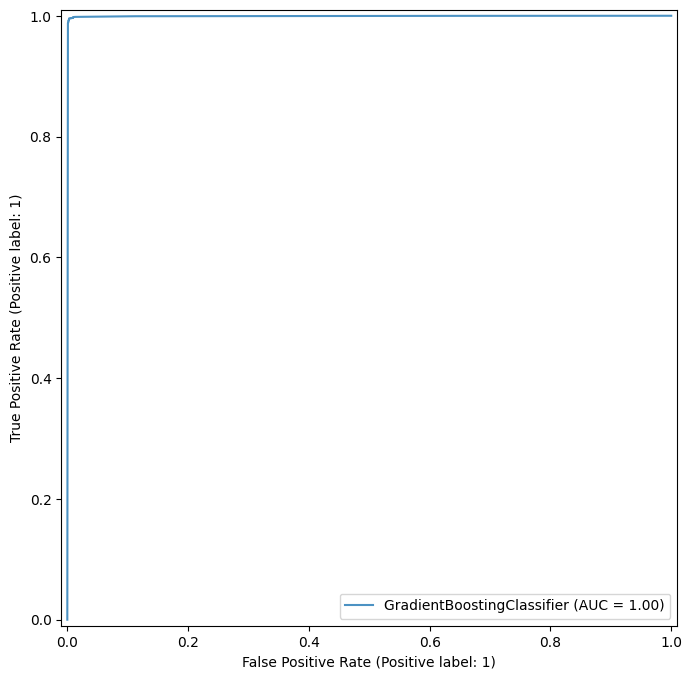

In [72]:
# Plotting ROC curve for Gradient Boosting Classifier
fig, ax = plt.subplots(figsize=(12,8))
ax = plt.gca()
grad_disp = RocCurveDisplay.from_estimator(grad_boost, tfidf_test, y_test, ax=ax, alpha=0.8)
plt.show()

In [73]:
#XG Boosting Classifier ROC
print(f"The area under the curve of the XG Boost is {roc_auc_score(y_test, xg_boost.predict_proba(tfidf_test)[:,1])}")

The area under the curve of the XG Boost is 0.9998029489990469


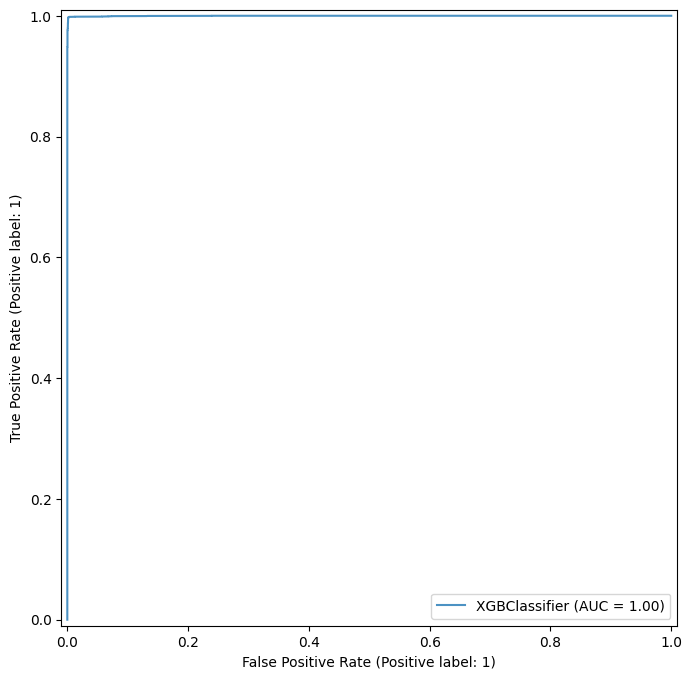

In [74]:
# Plotting ROC curve for XG Boosting Classifier
fig, ax = plt.subplots(figsize=(12,8))
ax = plt.gca()
xg_disp = RocCurveDisplay.from_estimator(xg_boost, tfidf_test, y_test, ax=ax, alpha=0.8)
plt.show()

In [75]:
# A class that gets scores
class get_scores(object):
    """ a class that gets the scores from a model"""
    def acc(model, x, y):
        """ A function that gets the accuracy score"""
        y_pred = model.predict(x)
        score = accuracy_score(y, y_pred)
        return score

    def precision (model, x, y):
        """ A function that gets the precision scores"""
        return precision_score(y, model.predict(x))

    def recall(model, x, y):
        """ A function that gets the recall scores"""
        return recall_score(y, model.predict(x))

    def f1 (model, x, y):
        """ A function that that gets the f1 scores"""
        return f1_score(y, model.predict(x))

In [76]:
# Creating instances of get_scores class
lr_scores  = get_scores
rf_scores = get_scores
gb_score = get_scores
ada_score = get_scores
xg_score = get_scores

In [77]:
# train summary table
train_summary_table = pd.DataFrame({'Model': [],
                              'Accuracy': [],
                              'Precision': [], 'Recall': [], 'F1 Score': [],
                              })

In [78]:
# train summary
train_summary_table.loc[0] = ["Logistic Regression",
                         lr_scores.acc(lr, tfidf_train, y_train),
                         lr_scores.precision(lr, tfidf_train, y_train),
                         lr_scores.recall(lr, tfidf_train, y_train),
                         lr_scores.f1(lr, tfidf_train, y_train)]

train_summary_table.loc[2] = ["Random Forest",
                        rf_scores.acc(rf, tfidf_train, y_train),
                        rf_scores.precision(rf, tfidf_train, y_train),
                        rf_scores.recall(rf, tfidf_train, y_train),
                        rf_scores.f1(rf, tfidf_train, y_train)]

train_summary_table.loc[2] = ["Gradient Boost",
                        gb_score.acc(grad_boost, tfidf_train, y_train),
                        gb_score.precision(grad_boost, tfidf_train, y_train),
                        gb_score.recall(grad_boost, tfidf_train, y_train),
                        gb_score.f1(grad_boost, tfidf_train, y_train)]

train_summary_table.loc[3] = ["Ada Boosting Classifier",
                        ada_score.acc(ada_boost, tfidf_train, y_train),
                        ada_score.precision(ada_boost, tfidf_train, y_train),
                        ada_score.recall(ada_boost, tfidf_train, y_train),
                        ada_score.f1(ada_boost, tfidf_train, y_train)]

train_summary_table.loc[4] = ["XG Boosting Classifier",
                        xg_score.acc(xg_boost, tfidf_train, y_train),
                        xg_score.precision(xg_boost, tfidf_train, y_train),
                        xg_score.recall(xg_boost, tfidf_train, y_train),
                        xg_score.f1(xg_boost, tfidf_train, y_train)]

In [79]:
# showing the train summary table
train_summary_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.990026,0.987715,0.991194,0.989452
2,Gradient Boost,0.996547,0.994333,0.998374,0.996350
3,Ada Boosting Classifier,0.995173,0.992584,0.997223,0.994898
4,XG Boosting Classifier,0.999968,1.000000,0.999932,0.999966


In [80]:
# test summary table
#summary table
test_summary_table = pd.DataFrame({'Model': [],
                              'Accuracy': [],
                              'Precision': [], 'Recall': [], 'F1 Score': [],
                              })

test_summary_table.loc[0] = ["Logistic Regression",
                         lr_scores.acc(lr, tfidf_test, y_test),
                         lr_scores.precision(lr, tfidf_test, y_test),
                         lr_scores.recall(lr, tfidf_test, y_test),
                         lr_scores.f1(lr, tfidf_test, y_test)]

test_summary_table.loc[1] = ["Random Forest",
                         rf_scores.acc(rf, tfidf_test, y_test),
                         rf_scores.precision(rf, tfidf_test, y_test),
                         rf_scores.recall(rf, tfidf_test, y_test),
                         rf_scores.f1(rf, tfidf_test, y_test)]

test_summary_table.loc[2] = ["Gradient Boost",
                        gb_score.acc(grad_boost, tfidf_test, y_test),
                        gb_score.precision(grad_boost, tfidf_test, y_test),
                        gb_score.recall(grad_boost, tfidf_test, y_test),
                        gb_score.f1(grad_boost, tfidf_test, y_test)]

test_summary_table.loc[3] = ["Ada Boosting Classifier",
                        ada_score.acc(ada_boost, tfidf_test, y_test),
                        ada_score.precision(ada_boost, tfidf_test, y_test),
                        ada_score.recall(ada_boost, tfidf_test, y_test),
                        ada_score.f1(ada_boost, tfidf_test, y_test)]

test_summary_table.loc[4] = ["XG Boosting Classifier",
                        xg_score.acc(xg_boost, tfidf_test, y_test),
                        xg_score.precision(xg_boost, tfidf_test, y_test),
                        xg_score.recall(xg_boost, tfidf_test, y_test),
                        xg_score.f1(xg_boost, tfidf_test, y_test)]

# showing the test summary table
test_summary_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.984635,0.983426,0.984646,0.984036
1,Random Forest,0.973521,0.971960,0.973015,0.972487
2,Gradient Boost,0.994480,0.992429,0.996123,0.994272
3,Ada Boosting Classifier,0.994779,0.992130,0.997053,0.994585
4,XG Boosting Classifier,0.997613,0.997056,0.997984,0.997520


In [81]:
# Creating a class that performs a cross validation score
class cross_v_scores(object):
    """ A class that performs cross validation"""
    def acc_score(model, x, y):
        """ A function that gets the mean cross validation accuracy"""
        mean_score = np.mean(cross_val_score(model, x, y, cv=3, scoring='accuracy'))
        return mean_score

    def mse(model, x, y):
        """ A function that calculates the mean squared error"""
        mean_mse = np.mean(-cross_val_score(model, x, y, cv=5, scoring="neg_mean_squared_error"))
        return mean_mse

In [82]:
lr_cv = cross_v_scores
rf_cv = cross_v_scores
ada_cv = cross_v_scores
grad_cv = cross_v_scores
xg_cv = cross_v_scores

In [83]:
# Creating a cross validation summary table
cross_validation_summary_table = pd.DataFrame({'Model': [],
                              'Accuracy': [],
                              'mean squared error': [],
                              })

In [84]:
# logistic regression
cross_validation_summary_table.loc[0] = ["Logistic Regression",
                                         lr_cv.acc_score(lr, tfidf_test, y_test),
                                         lr_cv.mse(lr, tfidf_test, y_test)]

# random forest
cross_validation_summary_table.loc[1] = ["Random Forest",
                                         rf_cv.acc_score(rf, tfidf_test, y_test),
                                         rf_cv.mse(rf, tfidf_test, y_test)]


# XG Boost
cross_validation_summary_table.loc[4] = ["XG Boosting Classifier",
                                         xg_cv.acc_score(xg_boost, tfidf_test, y_test),
                                         xg_cv.mse(xg_boost, tfidf_test, y_test)]

# showing the table
cross_validation_summary_table

,Model,Accuracy,mean squared error
0,Logistic Regression,0.976579,0.021780
1,Random Forest,0.970463,0.026479
4,XG Boosting Classifier,0.995077,0.004475


In [85]:
# Create a pipeline
pipe = Pipeline([('tfidf', TfidfVectorizer()),
                 ('xgb', XGBClassifier())])

pipe.fit(X_train, y_train)

pipe.predict(X_test)

array([1, 0, 0, ..., 0, 0, 1])

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

# Create a pipeline
pipe = Pipeline([('tfidf', TfidfVectorizer()),
                 ('xgb', XGBClassifier())])

# Fit the pipeline on the training data
pipe.fit(X_train, y_train)

# Predict on the test data
pipe.predict(X_test)

# file path for saving the model
model_path = (r"C:\Users\USER\Documents\myfinalproject", "model.pkl")

# New Section